In [1]:
print("sss")

sss


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# データを読み込み、すべての列を数値型に変換
data = pd.read_csv("run1019_none.csv")
# data.columns = data.columns.str.strip()  # 列名の空白を削除

a=len(data)
print(a)
# # すべての列を数値型に変換し、無効な値をNaNに置き換え
# data = data.apply(pd.to_numeric, errors='coerce')

# # NaNを含む行を削除
# data_cleaned = data.dropna()

2279055


In [3]:
data

,iEve,GRX,GRA,GRY,GRB,GRQ2timing,GRQ2charge,LASX,LASA,LASY,LASB,LASQ1timing,LASTOT
0,0,-9999.0000,-9999.000000,-9999.0000,-9999.000000,8503.65,58.0710,-9999.0000,-9999.000000,-9999.0000,-9999.000000,-9999.0,-9999.000
1,1,-85.0757,-0.004368,-10.4304,0.004936,45673.30,215.0850,-9999.0000,-9999.000000,-9999.0000,-9999.000000,45700.1,43.173
2,2,-9999.0000,-9999.000000,-9999.0000,-9999.000000,313692.00,72.6841,-9999.0000,-9999.000000,-9999.0000,-9999.000000,-9999.0,-9999.000
3,3,-9999.0000,-9999.000000,-9999.0000,-9999.000000,12416.60,172.7790,-9999.0000,-9999.000000,-9999.0000,-9999.000000,-9999.0,-9999.000
4,4,-9999.0000,-9999.000000,-9999.0000,-9999.000000,282502.00,32.8783,-288.1840,0.016686,11.8923,-0.024227,282168.0,261.607
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2279050,2279050,-9999.0000,-9999.000000,-9999.0000,-9999.000000,347001.00,76.6811,-9999.0000,-9999.000000,-9999.0000,-9999.000000,347134.0,-9999.000
2279051,2279051,-9999.0000,-9999.000000,-9999.0000,-9999.000000,260197.00,25.9268,-9999.0000,-9999.000000,-9999.0000,-9999.000000,260428.0,-9999.000
2279052,2279052,-9999.0000,-9999.000000,-9999.0000,-9999.000000,467954.00,72.9220,-72.3284,0.167751,25.0872,0.000395,467802.0,195.697
2279053,2279053,-9999.0000,-9999.000000,-9999.0000,-9999.000000,467954.00,72.9222,-9999.0000,-9999.000000,-9999.0000,-9999.000000,467802.0,199.213


In [4]:
GRX=data['GRX']
print(GRX)

0         -9999.0000
1           -85.0757
2         -9999.0000
3         -9999.0000
4         -9999.0000
             ...    
2279050   -9999.0000
2279051   -9999.0000
2279052   -9999.0000
2279053   -9999.0000
2279054   -9999.0000
Name: GRX, Length: 2279055, dtype: float64


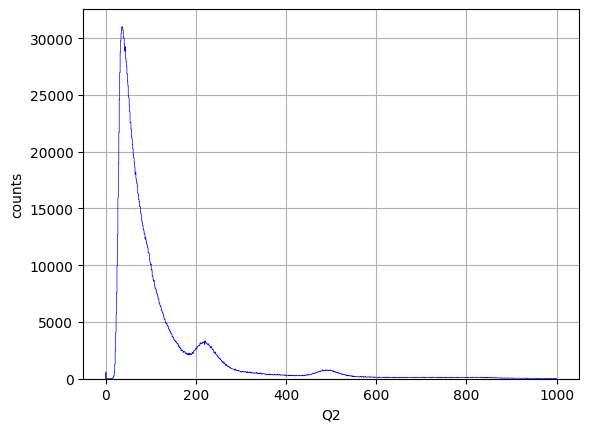

In [5]:
Q2=data['GRQ2charge']

variables=Q2
#hist range
range_min=0
range_max=1000
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('Q2')
ax.set_ylabel('counts')
ax.set_yscale('linear')


In [6]:
# 3列目（ilocは番号で指定）を抽出してリスト化
col_3_list = data.iloc[:, 2].tolist()
print(col_3_list[:20])

[-9999.0, -0.00436781, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, 0.0226671, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0]


In [7]:
print(col_3_list[:30])

[-9999.0, -0.00436781, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, 0.0226671, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0]


Text(0, 0.5, 'counts')

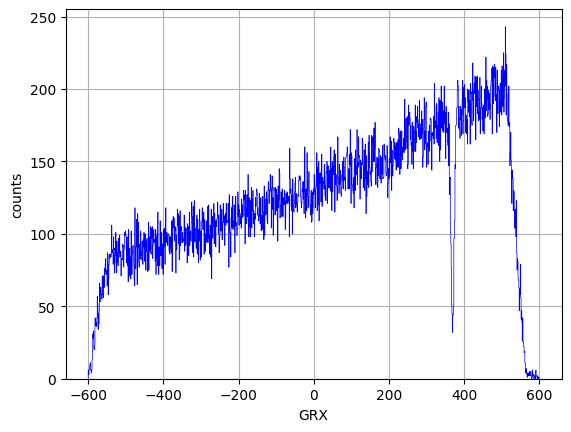

In [8]:
variables=GRX
#hist range
range_min=-600
range_max=600
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(col_3_list, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('GRX')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 143.690 ± 4.223
Mean: 100.000 ± 67.083
Sigma: 184.844 ± 173.058


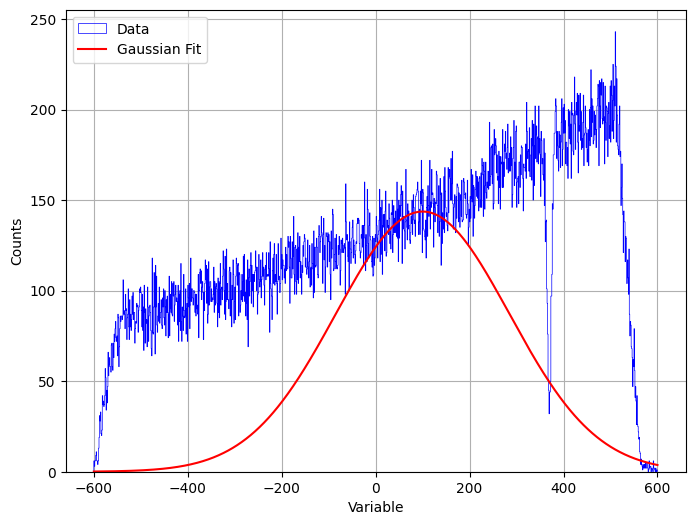

In [9]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = GRX
# Histogram range
hist_range_min = -600
hist_range_max = 600
# Bin width
bin_width = 1
# Fit range
fit_range_min = 30
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 3500
mean = 50
sigma = 10
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [10]:
data1 = pd.read_csv("run2005_none.csv")
data2 = pd.read_csv("run2006_none.csv")
data3 = pd.read_csv("run2007_none.csv")
data4 = pd.read_csv("run2008_none.csv")
data5 = pd.read_csv("run2009_none.csv")

GRX1=data1['GRX']
GRX2=data2['GRX']
GRX3=data3['GRX']
GRX4=data4['GRX']
GRX5=data5['GRX']



Text(0, 0.5, 'counts')

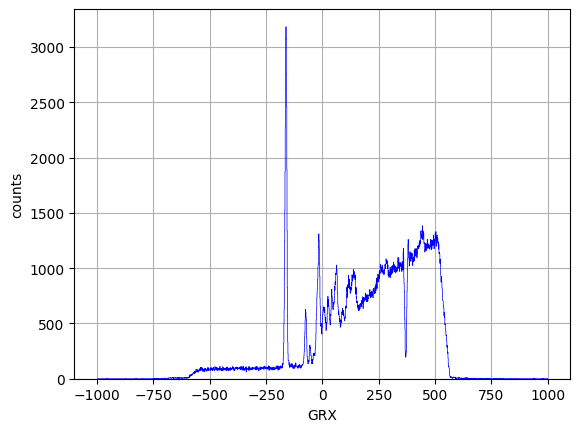

In [11]:
variables=GRX5
#hist range
range_min=-1000
range_max=1000
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(col_3_list, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('GRX')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 309.385 ± 1.880
Mean: -161.669 ± 0.029
Sigma: 4.141 ± 0.029


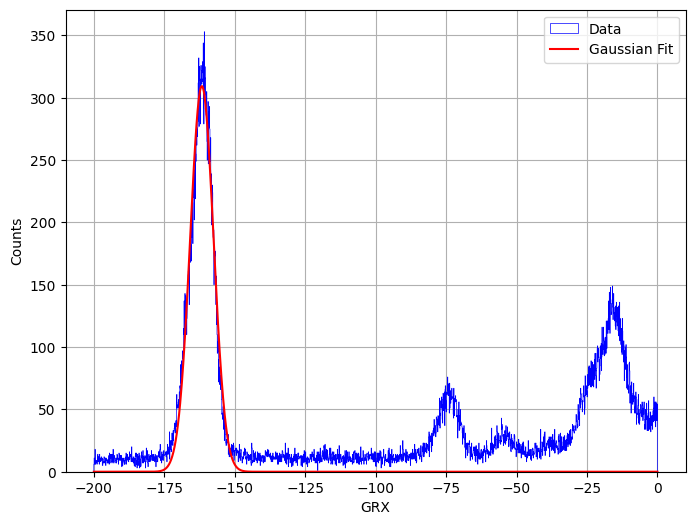

In [12]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = GRX5
# Histogram range
hist_range_min = -200
hist_range_max = 0
# Bin width
bin_width = 0.1
# Fit range
fit_range_min = -400
fit_range_max = -100
# Initial parameters for the Gaussian
Amp = 3000
mean = -200
sigma = 10
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('GRX')
ax.set_ylabel('Counts')
ax.legend()

In [13]:
B = [1044.924,1058.150,1021.481,1031.958,1037.196]
print(B)

[1044.924, 1058.15, 1021.481, 1031.958, 1037.196]


In [14]:
p0 = []
for n in B:
    p0.append(n * 300 * 3 * 0.001)
print(p0)

[940.4316000000001, 952.335, 919.3328999999999, 928.7622000000001, 933.4763999999999]


In [15]:
delta = []
for n in p0:
    delta.append((940.43 - n) / n)
print(delta)

[-1.7013464883217463e-06, -0.012500853166165359, 0.02294827042521819, 0.012562742109874656, 0.007449143866947308]


In [16]:
GRX_list = [61.208, 275.871, -505.847, -274.659, -161.669]

Weighted linear fit: y_axsis_variable = -0.0000440176 * x_axsis_variable + 0.0007645506


/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_81348/3872373745.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')


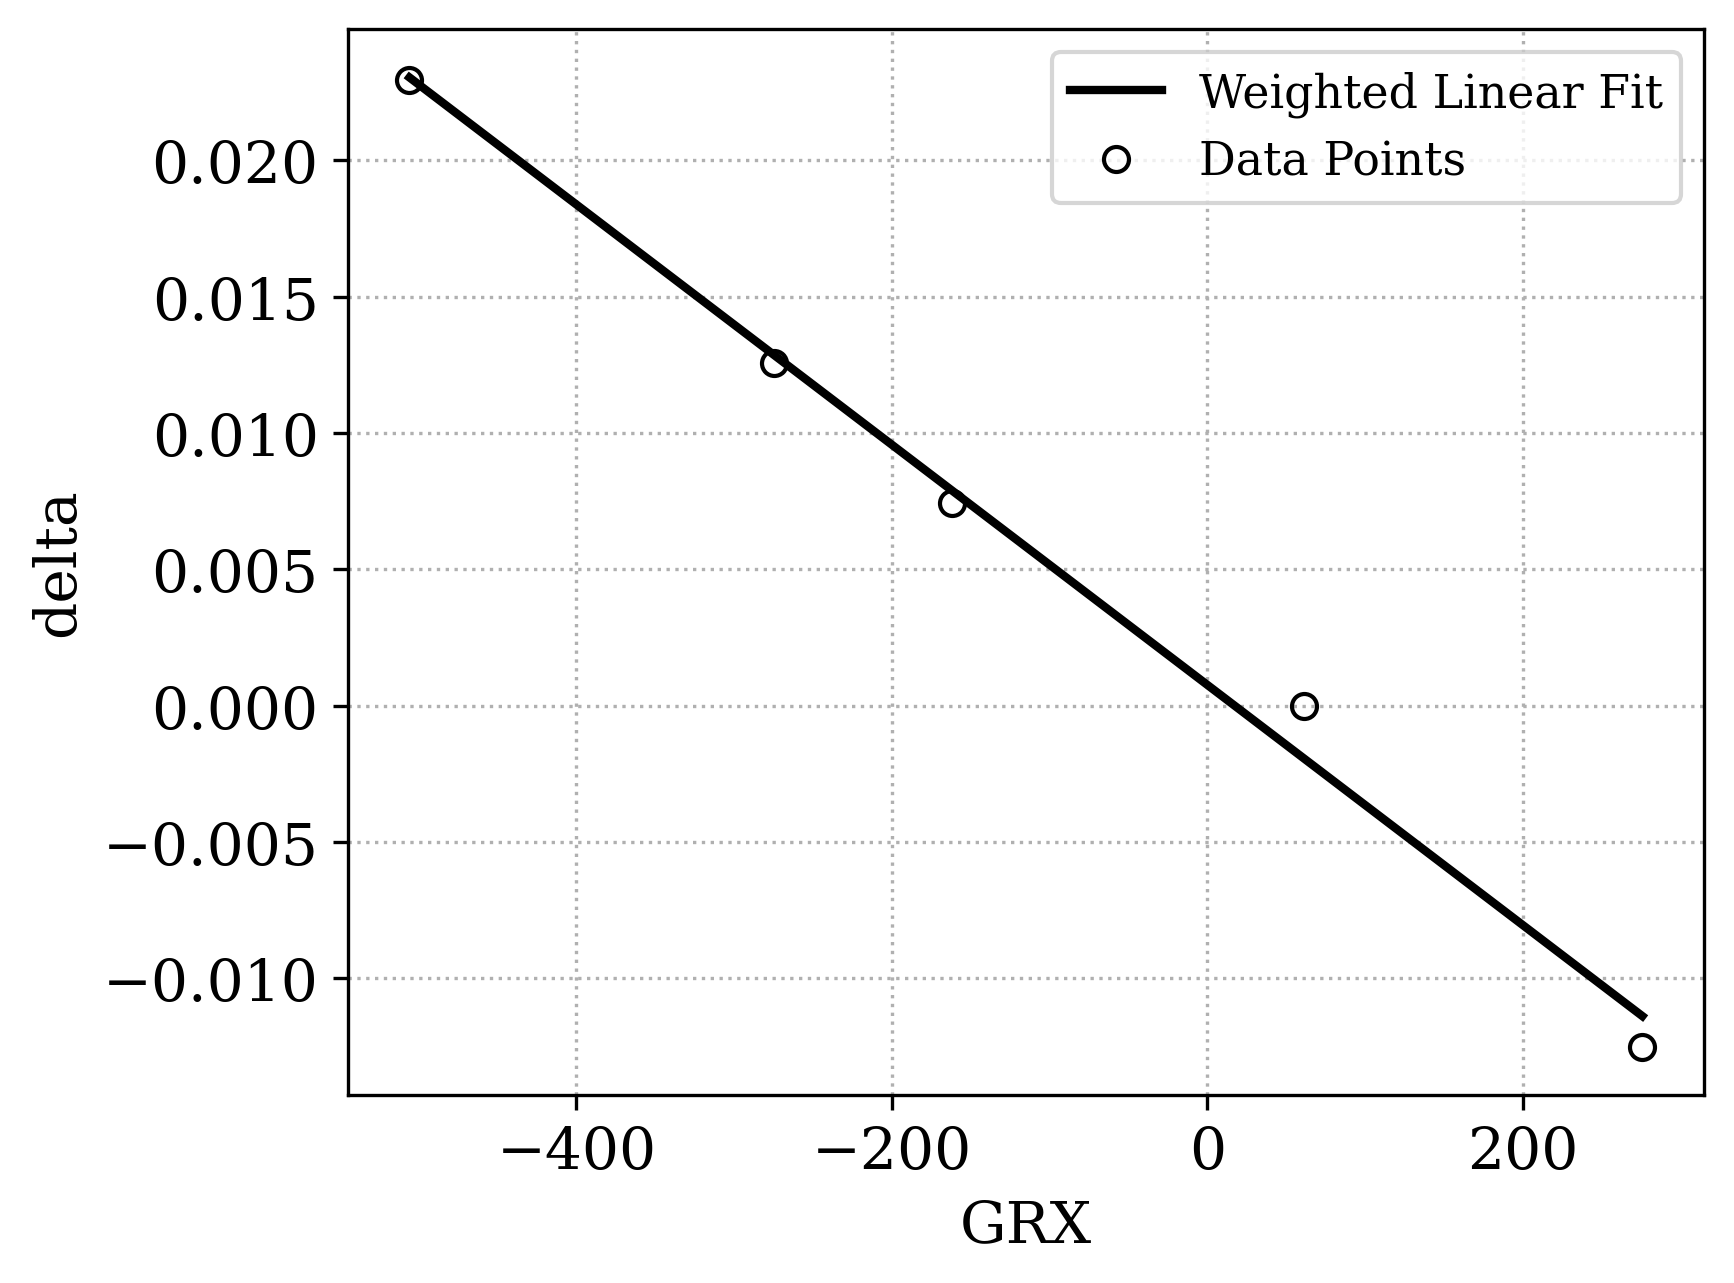

In [17]:
# # inpiut###############################
# x_axis_variable = np.array([-100,0,100])
# y_axis_variable = np.array([1,0,-1])

y_axis_variable = delta
x_axis_variable = GRX_list


# hist_range_min=-0.011
# hist_range_max=0.0009
#######################################


# ---------- 線形フィット ----------
coefficients_linear = np.polyfit(x_axis_variable, y_axis_variable, 1)
fit_func_linear = np.poly1d(coefficients_linear)
a_linear, b_linear = coefficients_linear

print(f"Weighted linear fit: y_axsis_variable = {a_linear:.10f} * x_axsis_variable + {b_linear:.10f}")

# ---------- 描画用 ----------
x_fit = np.linspace(min(x_axis_variable), max(x_axis_variable),1001)
y_fit_linear = fit_func_linear(x_fit)

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(6, 4.5))

# フィット直線
ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')

# エラーバー付きデータ点
ax.errorbar(x_axis_variable, y_axis_variable,
            fmt='o', markersize=6,
            capsize=4, capthick=1,
            markerfacecolor='none',       # 中を白抜き
            markeredgecolor='black',     # 枠線を黒に
            ecolor='gray',               # エラーバーの色
            label='Data Points')

# 軸ラベル
ax.set_xlabel('GRX')
ax.set_ylabel('delta')

# グリッド・凡例
ax.grid(True, linestyle=':')
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()


In [18]:
# データを読み込み、すべての列を数値型に変換
data = pd.read_csv("run1019_none.csv")
GRX=data['GRX']

In [19]:
p = []
for n in GRX:
    p.append((n * -0.0000454324 + 0.0017199490) * 832)

In [20]:
Tp = []
for n in p:
    Tp.append((n ** 2 - 2))

Text(0, 0.5, 'counts')

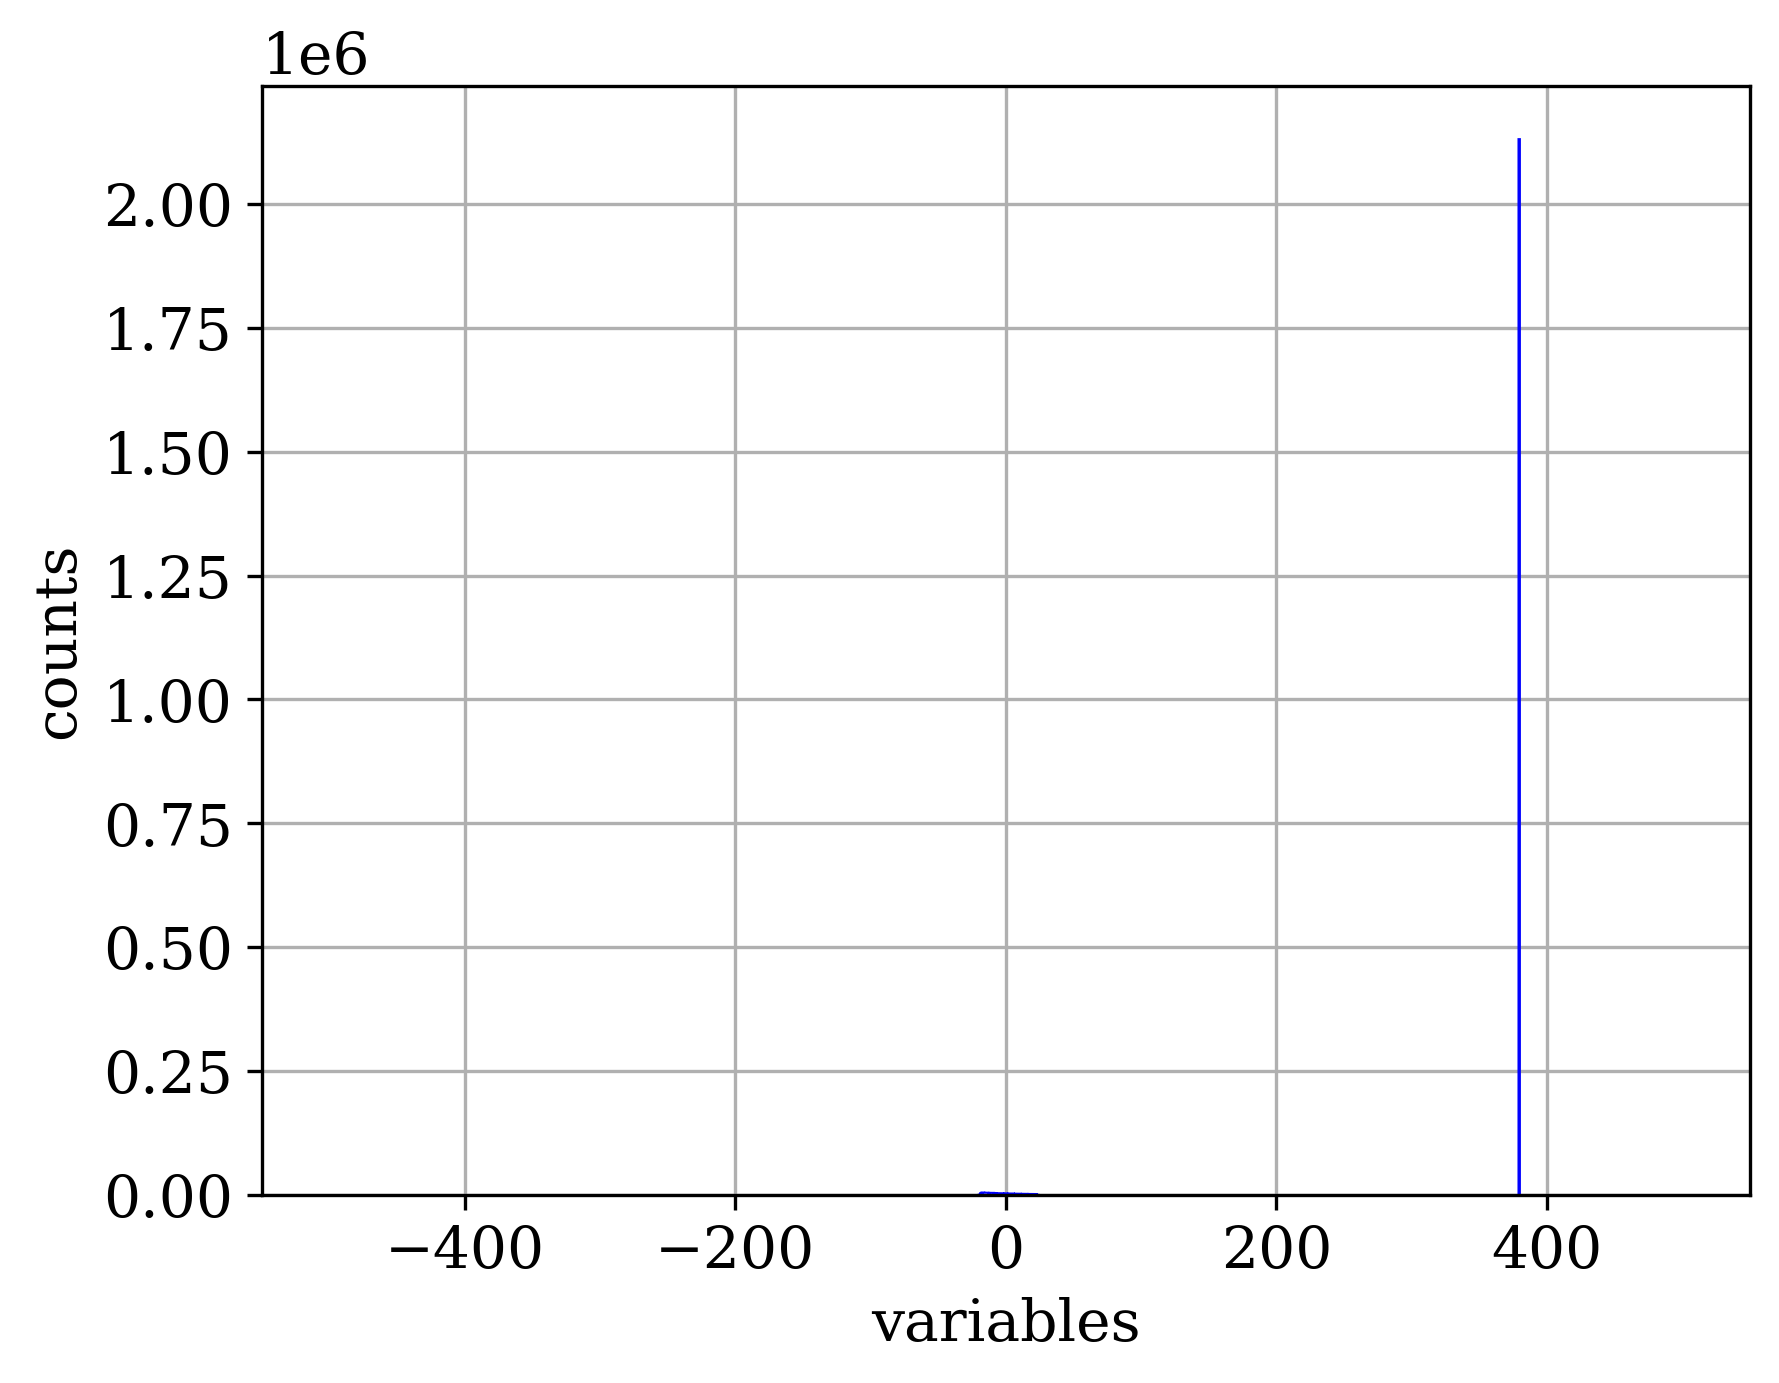

In [21]:
variables = p

#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variables')
ax.set_ylabel('counts')

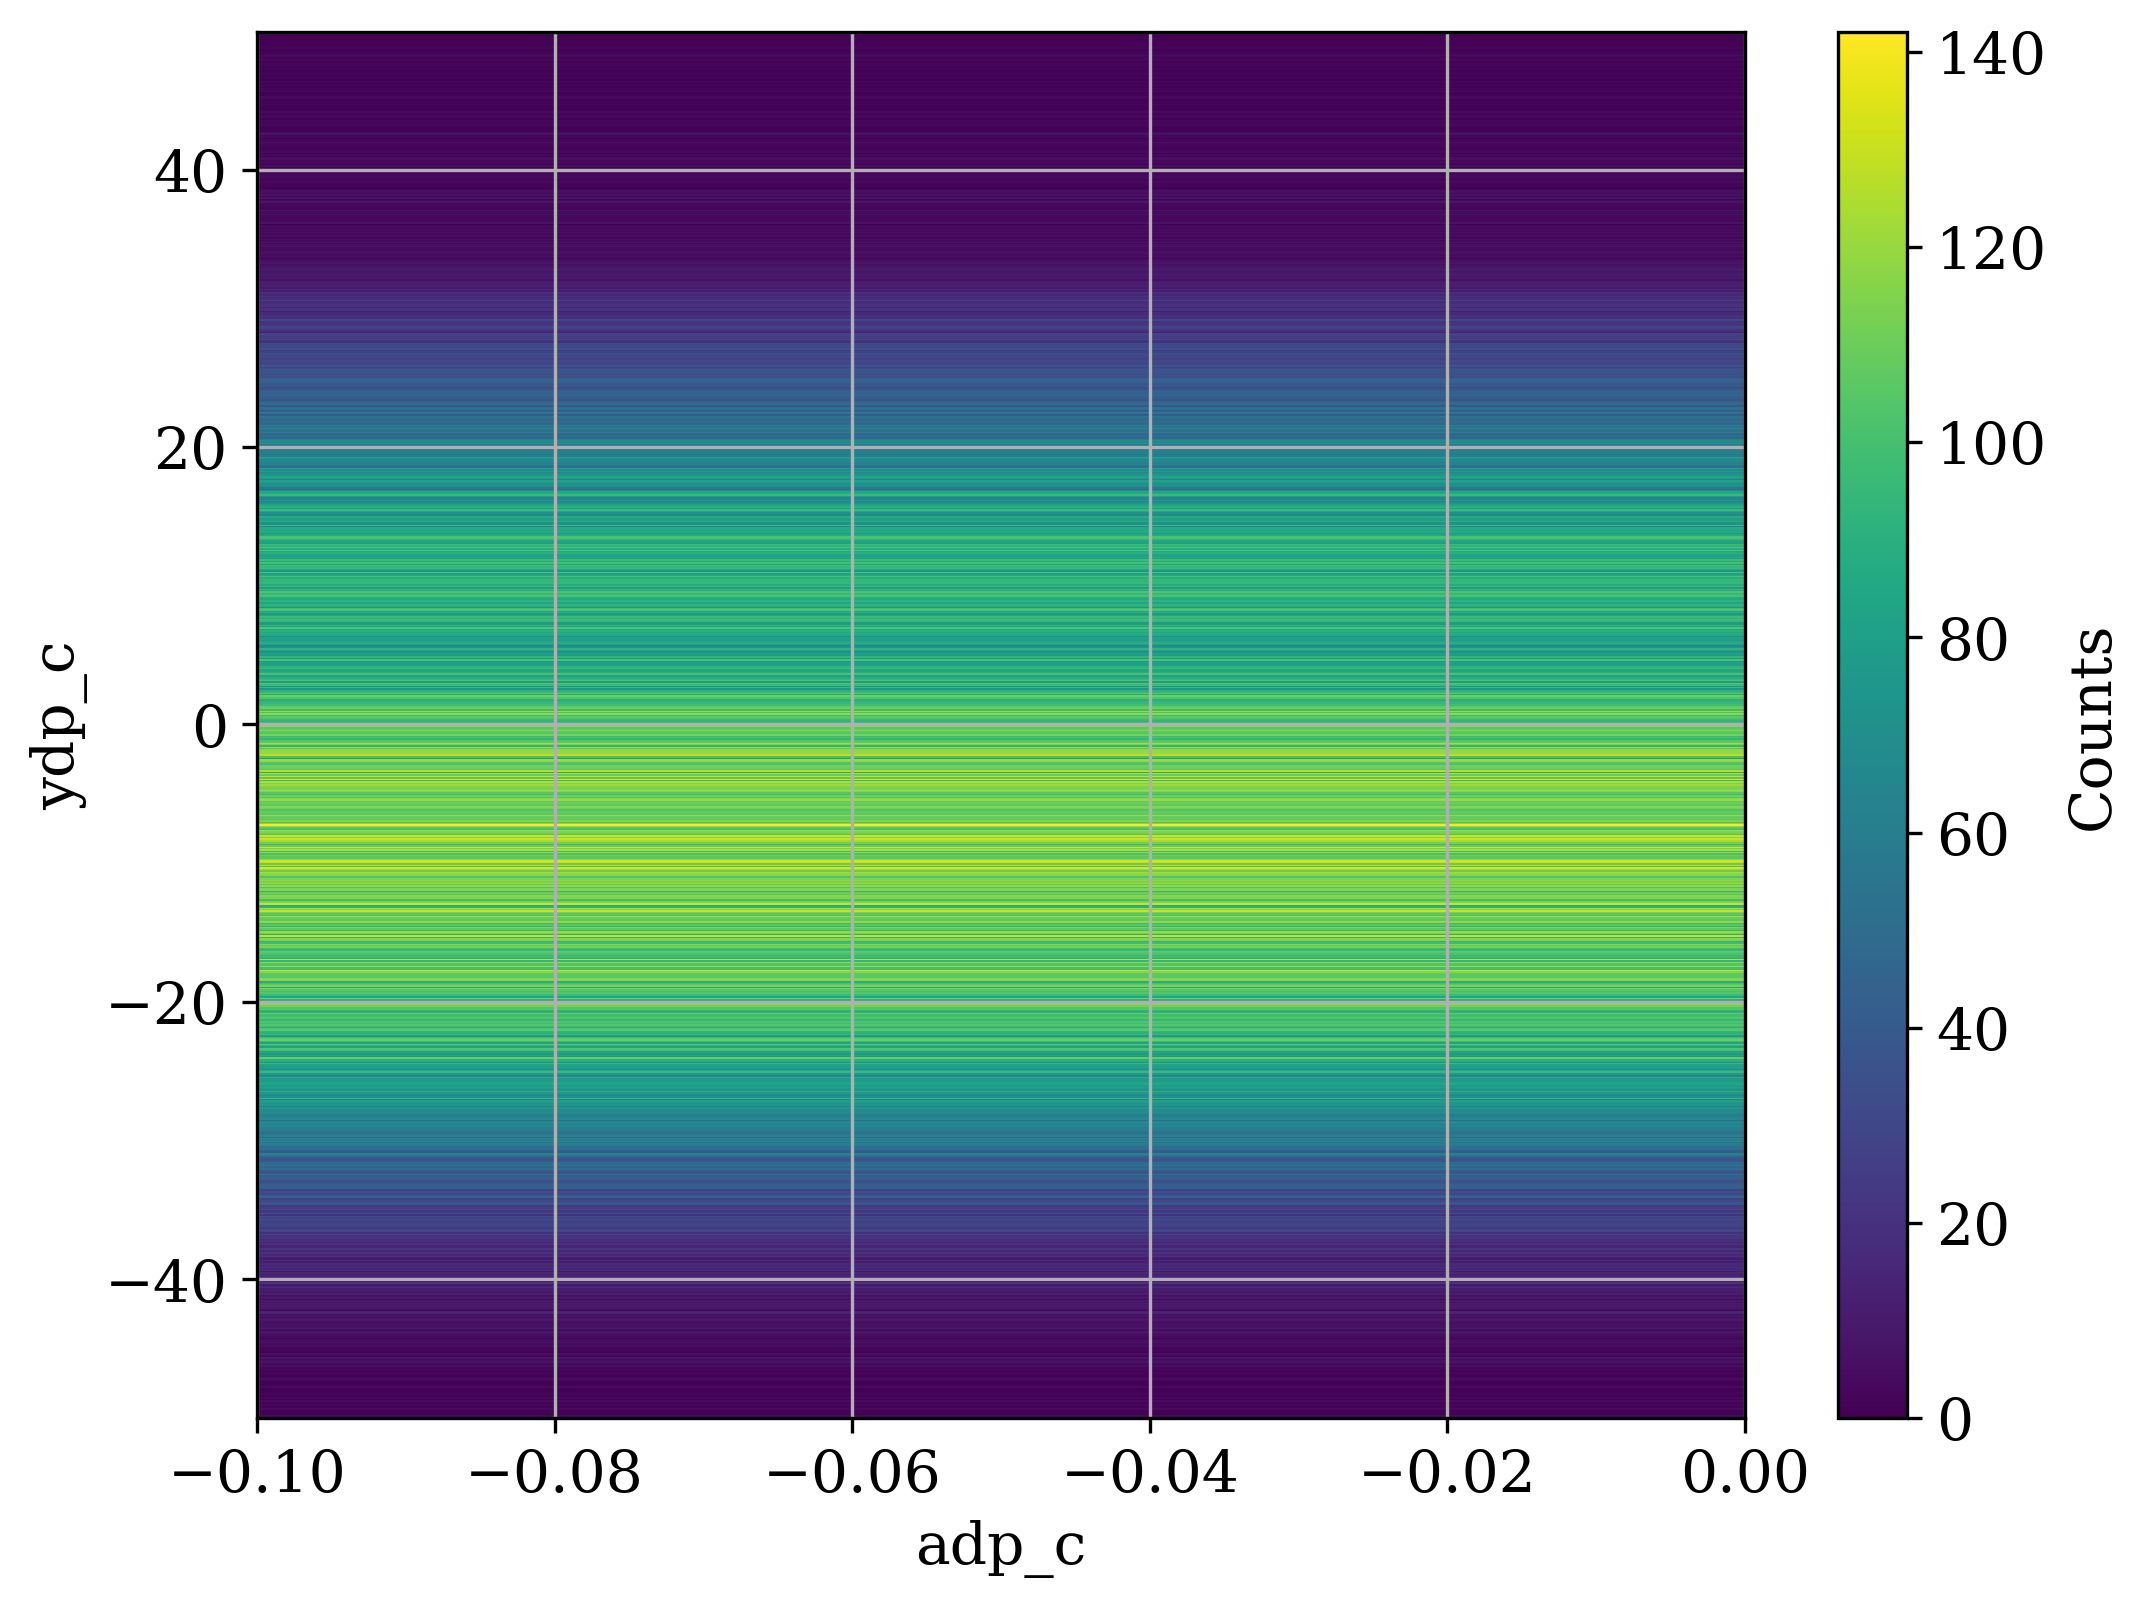

In [22]:
from matplotlib.colors import Normalize

col_4_list = data.iloc[:, 3].tolist()

#input
####################################################
#variables
x_axis_variable=col_3_list
y_axis_variable=col_4_list
#hist range
x_axis_range_min=-0.1
x_axis_range_max=0.1
y_axis_range_min=-50
y_axis_range_max=50
#bin width
x_bin_width=0.1
y_bin_width=0.1

######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 1)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('adp_c')
ax.set_ylabel('ydp_c')
ax.grid()

plt.show()

In [23]:
# データを読み込み、すべての列を数値型に変換
data1 = pd.read_csv("run2005_none.csv")
data1.columns = data1.columns.str.strip()  # 列名の空白を削除

a=len(data1)
print(a)
# すべての列を数値型に変換し、無効な値をNaNに置き換え
data1 = data1.apply(pd.to_numeric, errors='coerce')

# NaNを含む行を削除
data1_cleaned = data1.dropna()

5821253


In [24]:
# 3列目（ilocは番号で指定）を抽出してリスト化
col_3_list = data1.iloc[:, 2].tolist()
print(col_3_list[:20])

[-9999.0, -9999.0, 0.0135843, -9999.0, -9999.0, -9999.0, -9999.0, 0.00902726, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -0.011161]
